# ❤️ Heart Disease Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded")

Libraries loaded


In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 90
np.random.seed(42)
print("Settings done")

Settings done


In [4]:
df = pd.read_csv("heart_data.csv")
print("File loaded")

File loaded


In [5]:
print("Rows, Columns:", df.shape)

Rows, Columns: (297, 14)


In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [7]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0
296,35,1,3,126,282,0,2,156,1,0.0,0,0,2,1


In [8]:
df.sample(5, random_state=1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
138,44,0,2,118,242,0,0,149,0,0.3,1,1,0,0
233,57,1,3,132,207,0,0,168,1,0.0,0,0,2,0
51,49,1,1,130,266,0,0,171,0,0.6,0,0,0,0
290,41,1,3,110,172,0,2,158,0,0.0,0,0,2,1
242,55,0,3,180,327,0,1,117,1,3.4,1,0,0,1


The medical meaning of each column:

| Column | Meaning |
|---|---|
| `age` | age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | chest pain type (0=typical angina, 1=atypical, 2=non-anginal, 3=asymptomatic) |
| `trestbps` | resting blood pressure (mm Hg) |
| `chol` | cholesterol level (mg/dl) |
| `fbs` | fasting blood sugar > 120 mg/dl (1 = yes) |
| `restecg` | resting ECG result (0, 1, 2) |
| `thalach` | max heart rate achieved during exercise |
| `exang` | exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | slope of the ST segment (0, 1, 2) |
| `ca` | number of major vessels colored by fluoroscopy (0-3) |
| `thal` | thalassemia (0=normal, 1=fixed defect, 2=reversible defect) |
| `condition` | 🎯 **TARGET** — 0 = no disease, 1 = disease |

In [9]:
df.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'condition']

In [10]:
df.dtypes

age            int64
sex            int64
cp             int64
trestbps       int64
chol           int64
fbs            int64
restecg        int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
thal           int64
condition      int64
dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [12]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,2.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,0.60,0.68,0.84,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,0.96,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,2.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,56.00,1.00,2.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,0.00,0.00
75%,61.00,1.00,3.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,1.00,1.00,2.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,3.00,2.00,1.00


In [13]:
# Manually classify features so we can analyze them appropriately
continuous_features  = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
target = "condition"

print("Continuous:", continuous_features)
print("Categorical:", categorical_features)
print("Target:", target)

Continuous: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Target: condition


In [14]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

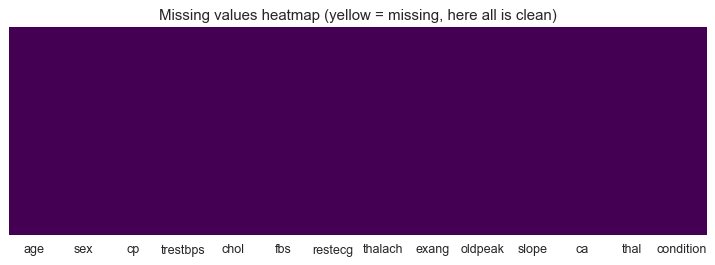

In [15]:
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing values heatmap (yellow = missing, here all is clean)")
plt.show()

In [16]:
df["condition"].value_counts()

condition
0    160
1    137
Name: count, dtype: int64

In [17]:
df["condition"].value_counts(normalize=True).round(3) * 100

condition
0    53.9
1    46.1
Name: proportion, dtype: float64

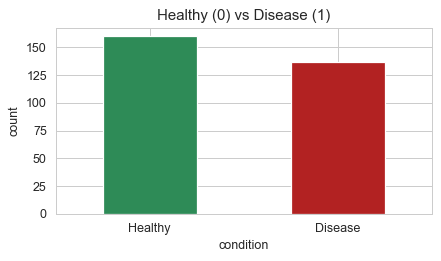

In [18]:
plt.figure(figsize=(5, 3))
df["condition"].value_counts().plot(kind="bar", color=["seagreen", "firebrick"])
plt.title("Healthy (0) vs Disease (1)")
plt.xticks([0, 1], ["Healthy", "Disease"], rotation=0)
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [19]:
df.groupby("sex")["condition"].mean().round(3)

sex
0    0.260
1    0.557
Name: condition, dtype: float64

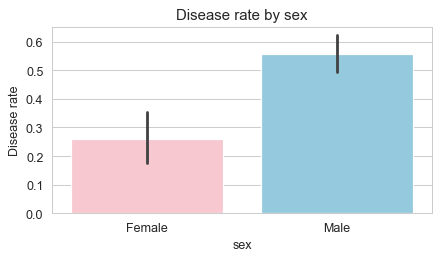

In [20]:
plt.figure(figsize=(5, 3))
sns.barplot(x="sex", y="condition", data=df, palette=["pink", "skyblue"])
plt.title("Disease rate by sex")
plt.xticks([0, 1], ["Female", "Male"])
plt.ylabel("Disease rate")
plt.tight_layout()
plt.show()

In [21]:
df.groupby("cp")["condition"].mean().round(3)

cp
0    0.304
1    0.184
2    0.217
3    0.725
Name: condition, dtype: float64

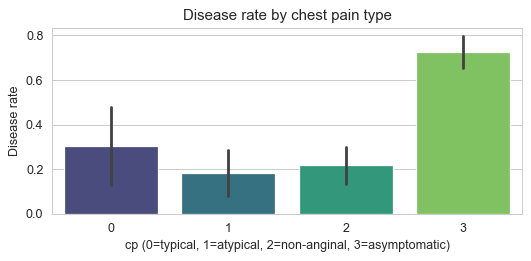

In [22]:
plt.figure(figsize=(6, 3))
sns.barplot(x="cp", y="condition", data=df, palette="viridis")
plt.title("Disease rate by chest pain type")
plt.xlabel("cp (0=typical, 1=atypical, 2=non-anginal, 3=asymptomatic)")
plt.ylabel("Disease rate")
plt.tight_layout()
plt.show()

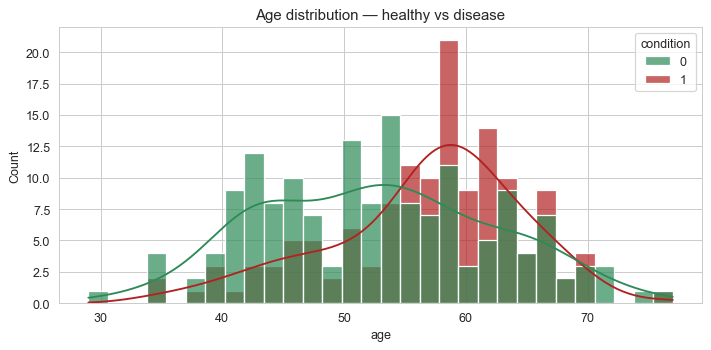

In [23]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="age", hue="condition", bins=30, kde=True,
             palette={0: "seagreen", 1: "firebrick"}, alpha=0.7)
plt.title("Age distribution — healthy vs disease")
plt.tight_layout()
plt.show()

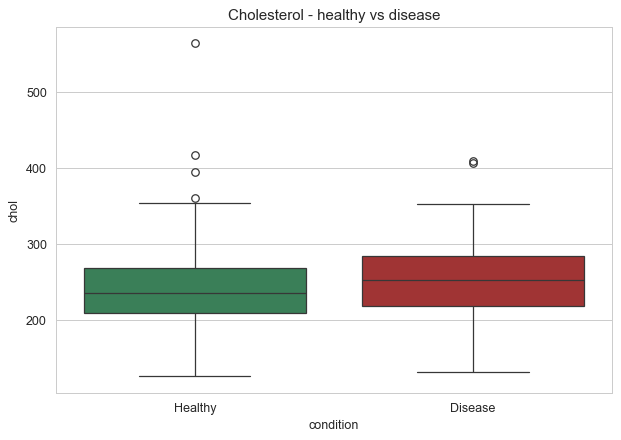

In [69]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="condition", y="chol", data=df, palette=["seagreen", "firebrick"])
plt.title("Cholesterol - healthy vs disease")
plt.xticks([0, 1], ["Healthy", "Disease"])
plt.tight_layout()
plt.show()

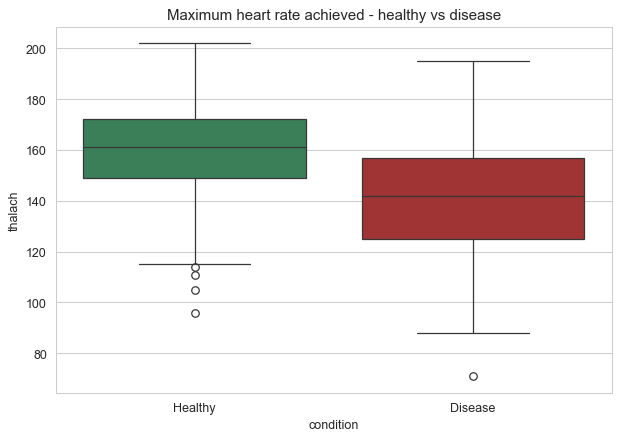

In [68]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="condition", y="thalach", data=df, palette=["seagreen", "firebrick"])
plt.title("Maximum heart rate achieved - healthy vs disease")
plt.xticks([0, 1], ["Healthy", "Disease"])
plt.tight_layout()
plt.show()

In [26]:
df.groupby("exang")["condition"].mean().round(3)

exang
0    0.315
1    0.763
Name: condition, dtype: float64

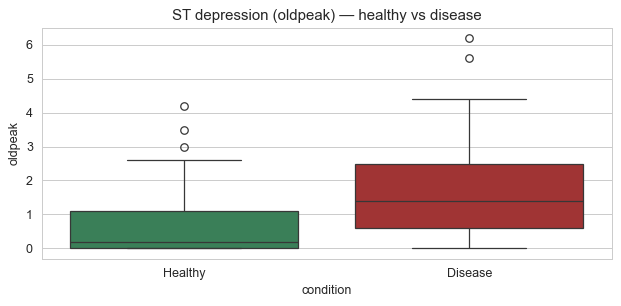

In [27]:
plt.figure(figsize=(7, 3.5))
sns.boxplot(x="condition", y="oldpeak", data=df, palette=["seagreen", "firebrick"])
plt.title("ST depression (oldpeak) — healthy vs disease")
plt.xticks([0, 1], ["Healthy", "Disease"])
plt.tight_layout()
plt.show()

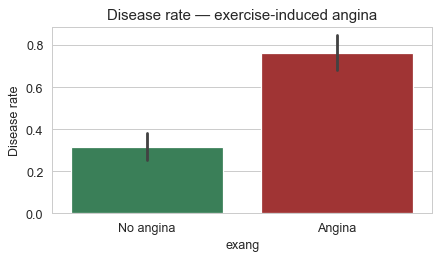

In [28]:
plt.figure(figsize=(5, 3))
sns.barplot(x="exang", y="condition", data=df, palette=["seagreen", "firebrick"])
plt.title("Disease rate — exercise-induced angina")
plt.xticks([0, 1], ["No angina", "Angina"])
plt.ylabel("Disease rate")
plt.tight_layout()
plt.show()

In [29]:
df.groupby("ca")["condition"].mean().round(3)

ca
0    0.259
1    0.677
2    0.816
3    0.850
Name: condition, dtype: float64

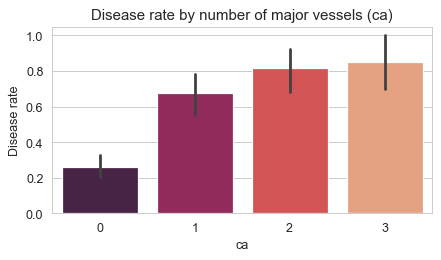

In [30]:
plt.figure(figsize=(5, 3))
sns.barplot(x="ca", y="condition", data=df, palette="rocket")
plt.title("Disease rate by number of major vessels (ca)")
plt.ylabel("Disease rate")
plt.tight_layout()
plt.show()

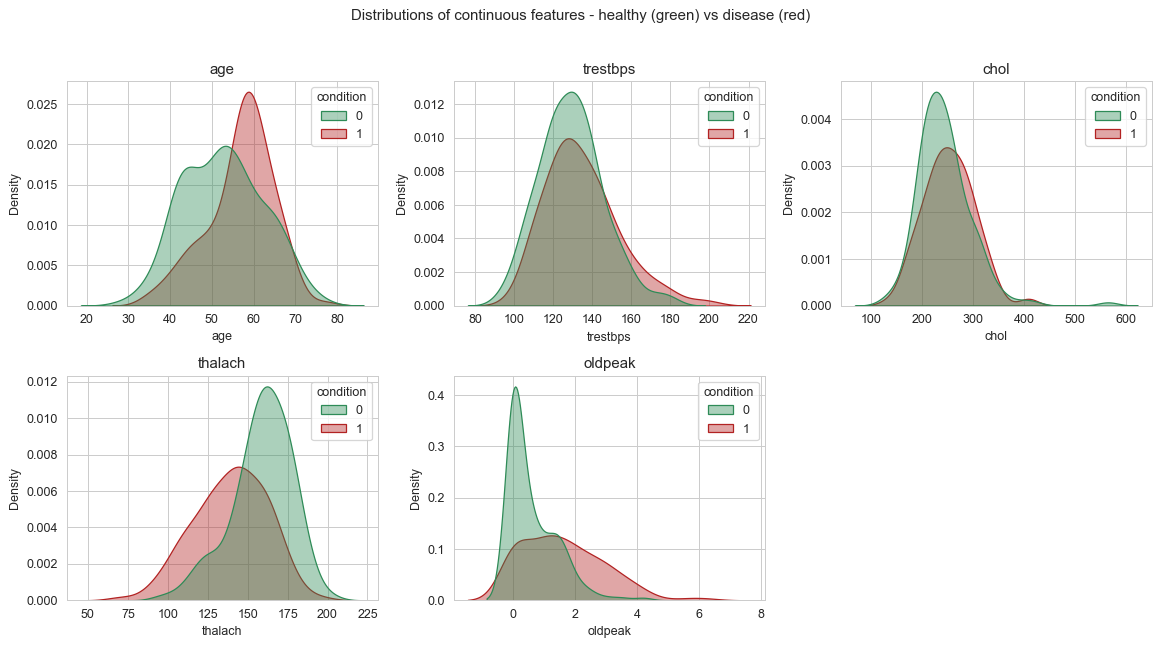

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.flat, continuous_features):
    sns.kdeplot(data=df, x=feat, hue="condition",
                palette={0: "seagreen", 1: "firebrick"}, ax=ax, fill=True, alpha=0.4)
    ax.set_title(feat)
axes.flat[-1].axis("off")    # turn off the empty 6th panel
plt.suptitle("Distributions of continuous features - healthy (green) vs disease (red)", y=1.02)
plt.tight_layout()
plt.show()

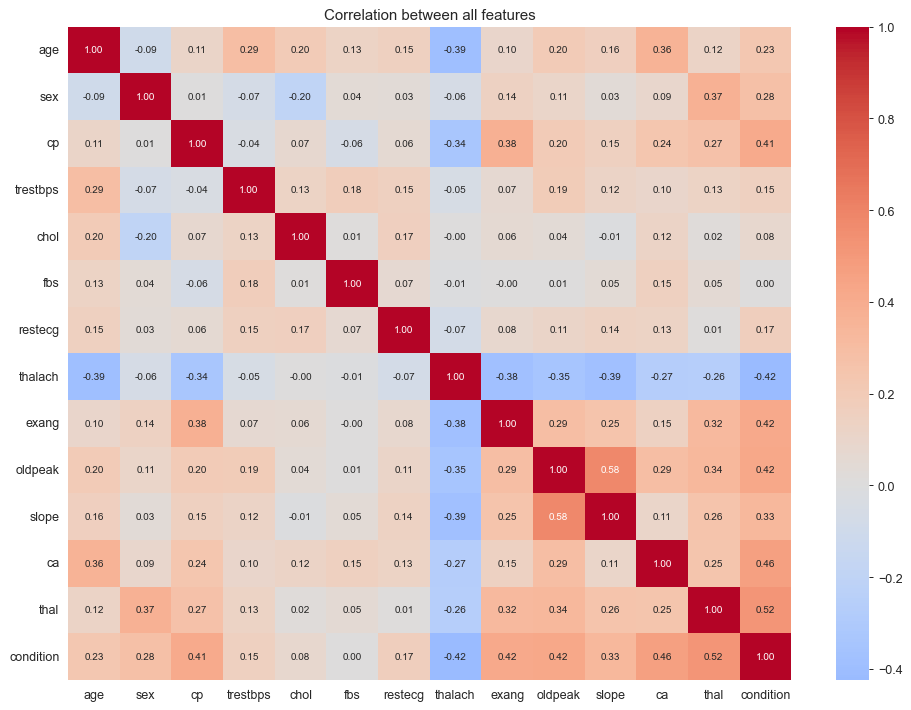

In [32]:
plt.figure(figsize=(11, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            annot_kws={"size": 8})
plt.title("Correlation between all features")
plt.tight_layout()
plt.show()

In [33]:
target_corr = df.corr()["condition"].drop("condition").sort_values(key=abs, ascending=False)
target_corr.round(3)

thal        0.521
ca          0.463
oldpeak     0.424
thalach    -0.424
exang       0.421
cp          0.409
slope       0.333
sex         0.278
age         0.227
restecg     0.166
trestbps    0.153
chol        0.080
fbs         0.003
Name: condition, dtype: float64

In [66]:
#feature engineering

In [34]:
df["age_group"] = pd.cut(df["age"],
                          bins=[0, 40, 55, 65, 100],
                          labels=["Young", "Middle", "Senior", "Elderly"])
df["age_group"].value_counts()

age_group
Middle     129
Senior     118
Elderly     33
Young       17
Name: count, dtype: int64

In [35]:
df.groupby("age_group", observed=True)["condition"].mean().round(3)

age_group
Young      0.353
Middle     0.318
Senior     0.627
Elderly    0.485
Name: condition, dtype: float64

In [36]:
# A simple medical risk score combining known risk factors
df["risk_score"] = (
    (df["age"] > 55).astype(int) +
    (df["chol"] > 240).astype(int) +
    (df["trestbps"] > 140).astype(int) +
    df["exang"] +
    (df["ca"] >= 1).astype(int)
)
df["risk_score"].value_counts().sort_index()

risk_score
0    43
1    78
2    66
3    69
4    34
5     7
Name: count, dtype: int64

In [37]:
df.groupby("risk_score")["condition"].mean().round(3)

risk_score
0    0.070
1    0.282
2    0.379
3    0.768
4    0.794
5    1.000
Name: condition, dtype: float64

In [38]:
df["chol_per_age"] = df["chol"] / df["age"]
df[["chol", "age", "chol_per_age"]].head()

,chol,age,chol_per_age
0,234,69,3.391304
1,239,69,3.463768
2,226,66,3.424242
3,282,65,4.338462
4,211,64,3.296875


In [39]:
# Theoretical max HR is 220 - age. Reserve = how much short of theoretical max
df["hr_reserve"] = 220 - df["age"] - df["thalach"]
df[["age", "thalach", "hr_reserve"]].head()

,age,thalach,hr_reserve
0,69,131,20
1,69,151,0
2,66,114,40
3,65,174,-19
4,64,144,12


In [40]:
df_encoded = pd.get_dummies(df, columns=["age_group"], drop_first=True, dtype=int)
print("New shape:", df_encoded.shape)
df_encoded.head()

New shape: (297, 20)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition,risk_score,chol_per_age,hr_reserve,age_group_Middle,age_group_Senior,age_group_Elderly
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0,3,3.391304,20,0,0,1
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0,2,3.463768,0,0,0,1
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0,2,3.424242,40,0,0,1
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1,3,4.338462,-19,0,1,0
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0,2,3.296875,12,0,1,0


In [41]:
X = df_encoded.drop(columns=["condition"])
y = df_encoded["condition"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (297, 19)
y shape: (297,)


In [42]:
print("Final features used:")
for col in X.columns:
    print(" -", col)

Final features used:
 - age
 - sex
 - cp
 - trestbps
 - chol
 - fbs
 - restecg
 - thalach
 - exang
 - oldpeak
 - slope
 - ca
 - thal
 - risk_score
 - chol_per_age
 - hr_reserve
 - age_group_Middle
 - age_group_Senior
 - age_group_Elderly


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training:", X_train.shape, " ", y_train.shape)
print("Testing: ", X_test.shape,  " ", y_test.shape)

Training: (237, 19)   (237,)
Testing:  (60, 19)   (60,)


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("After scaling: mean ≈ 0, std ≈ 1 on training set")
print(f"  Train mean: {X_train_s.mean():.4f}")
print(f"  Train std:  {X_train_s.std():.4f}")

After scaling: mean ≈ 0, std ≈ 1 on training set
  Train mean: -0.0000
  Train std:  1.0000


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression accuracy: {acc_lr:.4f}")

Logistic Regression accuracy: 0.8833


In [46]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN accuracy: {acc_knn:.4f}")

KNN accuracy: 0.8333


In [47]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree accuracy: {acc_dt:.4f}")

Decision Tree accuracy: 0.8167


In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest accuracy: {acc_rf:.4f}")

Random Forest accuracy: 0.8500


In [49]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=1.0, probability=True, random_state=42)
svm.fit(X_train_s, y_train)
y_pred_svm = svm.predict(X_test_s)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM accuracy: {acc_svm:.4f}")

SVM accuracy: 0.8500


In [50]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting accuracy: {acc_gb:.4f}")

Gradient Boosting accuracy: 0.7833


In [51]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_s, y_train)
y_pred_nb = nb.predict(X_test_s)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes accuracy: {acc_nb:.4f}")

Naive Bayes accuracy: 0.8167


In [52]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest",
              "SVM", "Gradient Boosting", "Naive Bayes"],
    "Accuracy": [acc_lr, acc_knn, acc_dt, acc_rf, acc_svm, acc_gb, acc_nb],
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results

,Model,Accuracy
0,Logistic Regression,0.883333
1,SVM,0.850000
2,Random Forest,0.850000
3,KNN,0.833333
4,Decision Tree,0.816667
5,Naive Bayes,0.816667
6,Gradient Boosting,0.783333


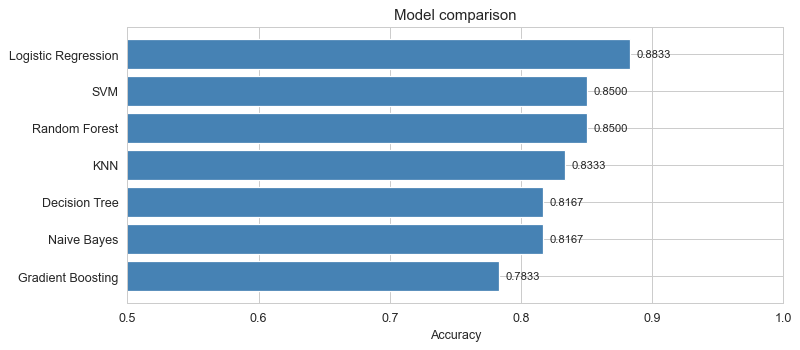

In [53]:
plt.figure(figsize=(9, 4))
bars = plt.barh(results["Model"], results["Accuracy"], color="steelblue")
plt.xlim(0.5, 1.0)
plt.xlabel("Accuracy")
plt.title("Model comparison")
for bar, acc in zip(bars, results["Accuracy"]):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{acc:.4f}", va="center", fontsize=9)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [70]:
all_models = {
    "Logistic Regression": (lr, y_pred_lr, True),       # True = needs scaling
    "KNN": (knn, y_pred_knn, True),
    "Decision Tree": (dt, y_pred_dt, False),
    "Random Forest": (rf, y_pred_rf, False),
    "SVM": (svm, y_pred_svm, True),
    "Gradient Boosting": (gb, y_pred_gb, False),
    "Naive Bayes": (nb, y_pred_nb, True),
}
best_name = results.iloc[0]["Model"]
best_model, best_pred, best_needs_scaling = all_models[best_name]
print(f"Best model: {best_name}")

Best model: Logistic Regression


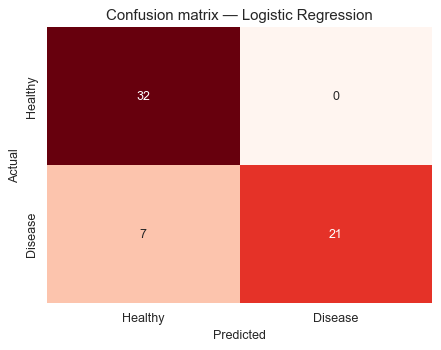

  True  Negatives (healthy → healthy):      32
  False Positives (healthy → disease):      0
  False Negatives (disease → healthy)  ⚠️ :  7   ← MISSED DIAGNOSES
  True  Positives (disease → disease):      21


In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Healthy", "Disease"],
            yticklabels=["Healthy", "Disease"], cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  True  Negatives (healthy → healthy):      {tn}")
print(f"  False Positives (healthy → disease):      {fp}")
print(f"  False Negatives (disease → healthy)  ⚠️ :  {fn}   ← MISSED DIAGNOSES")
print(f"  True  Positives (disease → disease):      {tp}")

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, best_pred,
                            target_names=["Healthy", "Disease"],
                            digits=4))

              precision    recall  f1-score   support

     Healthy     0.8205    1.0000    0.9014        32
     Disease     1.0000    0.7500    0.8571        28

    accuracy                         0.8833        60
   macro avg     0.9103    0.8750    0.8793        60
weighted avg     0.9043    0.8833    0.8808        60



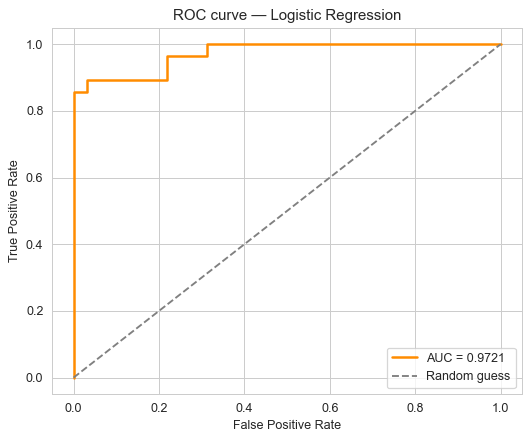

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score

X_for_proba = X_test_s if best_needs_scaling else X_test
y_proba = best_model.predict_proba(X_for_proba)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

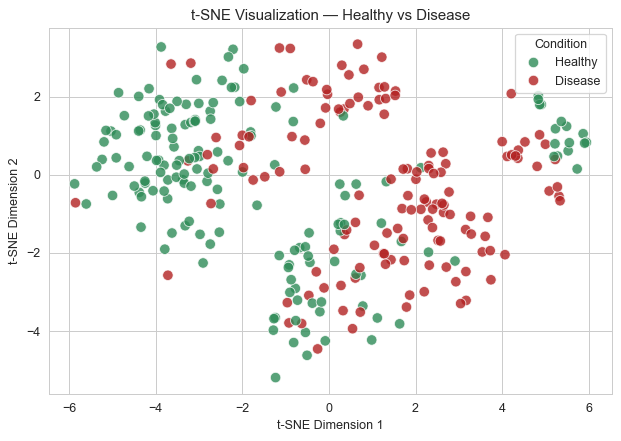

In [58]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Scale features before t-SNE
scaler_tsne = StandardScaler()
X_scaled_tsne = scaler_tsne.fit_transform(X)

# Apply t-SNE to reduce features to 2 dimensions
tsne = TSNE(
    n_components=2,
    perplexity=100,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled_tsne)

# Create dataframe for plotting
tsne_df = pd.DataFrame({
    "TSNE_1": X_tsne[:, 0],
    "TSNE_2": X_tsne[:, 1],
    "condition": y
})

# Plot t-SNE
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=tsne_df,
    x="TSNE_1",
    y="TSNE_2",
    hue="condition",
    palette={0: "seagreen", 1: "firebrick"},
    s=70,
    alpha=0.8
)

plt.title("t-SNE Visualization — Healthy vs Disease")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(
    handles,
    ["Healthy", "Disease"],
    title="Condition"
)
plt.tight_layout()
plt.show()

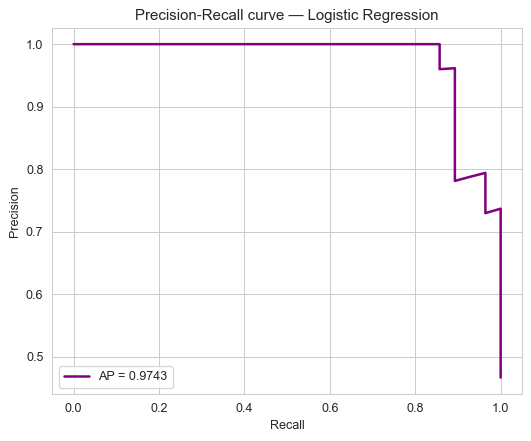

In [59]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(rec, prec, color="purple", linewidth=2, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

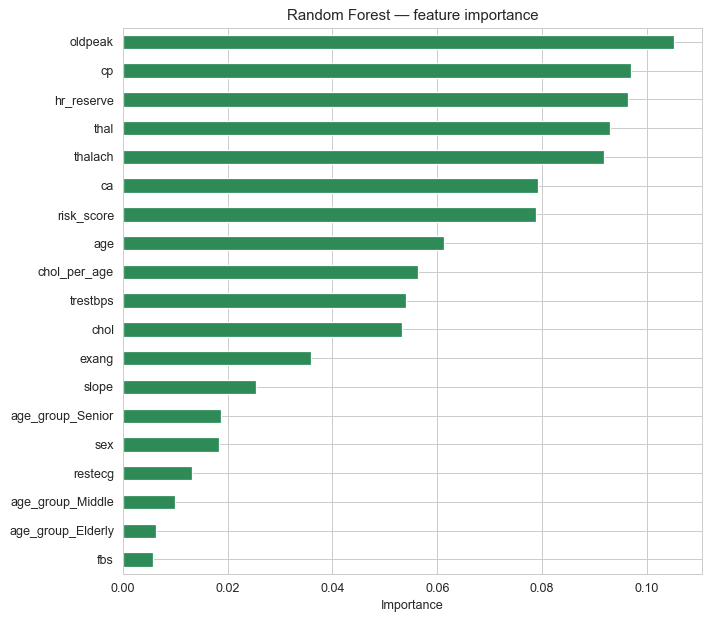

In [60]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 7))
importances.plot(kind="barh", color="seagreen")
plt.title("Random Forest — feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [61]:
importances.tail(5).iloc[::-1]

oldpeak       0.105235
cp            0.096932
hr_reserve    0.096373
thal          0.092900
thalach       0.091761
dtype: float64

In [62]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
print("5-fold CV accuracies:", cv_scores.round(4))
print(f"Mean: {cv_scores.mean():.4f}  (±{cv_scores.std():.4f})")

5-fold CV accuracies: [0.5833 0.8167 0.8136 0.9322 0.5763]
Mean: 0.7444  (±0.1411)


In [63]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Pipelines for models that need scaling
needs_scaling = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "SVM":                 SVC(kernel="rbf", probability=True, random_state=42),
    "Naive Bayes":         GaussianNB(),
}
no_scaling = {
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv_results = {}
for name, model in needs_scaling.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
    cv_results[name] = (scores.mean(), scores.std())

for name, model in no_scaling.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    cv_results[name] = (scores.mean(), scores.std())

cv_df = pd.DataFrame(cv_results, index=["mean", "std"]).T.sort_values("mean", ascending=False)
cv_df.round(4)

,mean,std
Naive Bayes,0.7947,0.1234
SVM,0.7914,0.1183
Logistic Regression,0.7847,0.1094
KNN,0.7745,0.1180
Random Forest,0.7444,0.1411
Gradient Boosting,0.7042,0.1267
Decision Tree,0.6871,0.1462


In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
acc_best = accuracy_score(y_test, best_rf.predict(X_test))
print(f"Test accuracy with tuned model: {acc_best:.4f}")

Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 0.8232
Test accuracy with tuned model: 0.8500


In [65]:
# A hypothetical patient
new_patient = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

new_patient["age"]       = 58
new_patient["sex"]       = 1            # male
new_patient["cp"]        = 3            # asymptomatic chest pain
new_patient["trestbps"]  = 145          # high BP
new_patient["chol"]      = 285          # high cholesterol
new_patient["fbs"]       = 0
new_patient["restecg"]   = 1
new_patient["thalach"]   = 125          # low max heart rate
new_patient["exang"]     = 1            # has exercise angina
new_patient["oldpeak"]   = 2.5
new_patient["slope"]     = 1
new_patient["ca"]        = 2            # 2 blocked vessels
new_patient["thal"]      = 2            # reversible defect
new_patient["risk_score"] = 4
new_patient["chol_per_age"] = 285 / 58
new_patient["hr_reserve"]   = 220 - 58 - 125
# age_group_Senior gets a 1 (since age=58 falls in the 55-65 bin)
if "age_group_Senior" in new_patient.columns:
    new_patient["age_group_Senior"] = 1

prediction = best_rf.predict(new_patient)[0]
probability = best_rf.predict_proba(new_patient)[0]

print("Predicted:", "🔴 HAS DISEASE" if prediction == 1 else "🟢 HEALTHY")
print(f"Confidence: healthy = {probability[0]:.2%}, disease = {probability[1]:.2%}")

Predicted: 🔴 HAS DISEASE
Confidence: healthy = 3.27%, disease = 96.73%
